In [ ]:
# KNN from scratch

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.cm as cm

In [38]:
import numpy as np
from collections import Counter

class KNNClassifier:

    def __init__(self, k=3, distance_func=None):
        self.k = k
        self.distance_func = distance_func if distance_func else self._euclidean_distance

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _manhattan_distance(self, x1, x2):
        return np.sum(np.abs(x1 - x2))

    def _minkowski_distance(self, x1, x2, p=3):
        return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)

    def predict(self, X):

        predictions = []

        for x in X:

            distances = [self.distance_func(x, x_train) for x_train in self.X_train]

            k_indices = np.argsort(distances)[:self.k]

            k_neighbor_labels = self.y_train[k_indices]

            predicted_label = Counter(k_neighbor_labels).most_common(1)[0][0]

            predictions.append(predicted_label)

        return np.array(predictions)


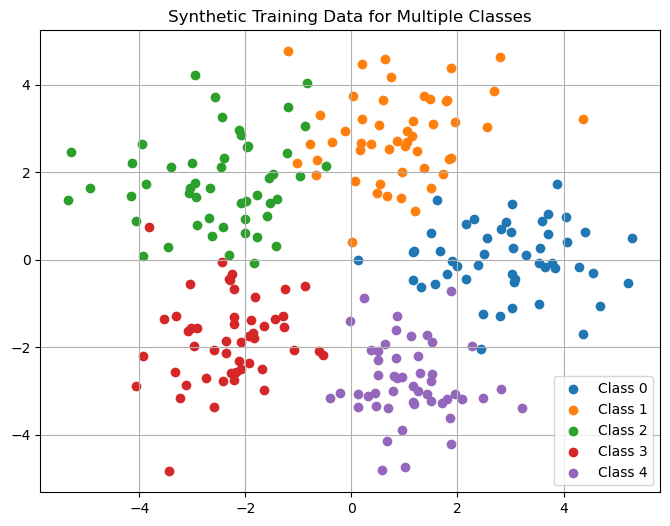

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def generate_synthetic_data(m=3, num_points_per_class=100, cluster_std=1.0):
    np.random.seed(40)
    X = []
    y = []
    means = []

    for i in range(m):
        angle = 2 * np.pi * i / m
        radius = 3

        mean = [radius * np.cos(angle), radius * np.sin(angle)]
        means.append(mean)

        cov = [[cluster_std, 0], [0, cluster_std]]

        class_data = np.random.multivariate_normal(mean, cov, num_points_per_class)

        X.append(class_data)
        y += [i] * num_points_per_class

    X = np.vstack(X)
    y = np.array(y)

    return X, y, means


m = 5
num_points_per_class = 50
cluster_std = 1.0

X, y, class_means = generate_synthetic_data(
    m=m,
    num_points_per_class=num_points_per_class,
    cluster_std=cluster_std
)

plt.figure(figsize=(8,6))

colors = plt.colormaps['tab10'].colors

for i in range(m):
    plt.scatter(X[y == i, 0], X[y == i, 1], color=colors[i], label=f'Class {i}')

plt.title('Synthetic Training Data for Multiple Classes')
plt.legend()
plt.grid(True)
plt.show()


# Scikit-learn KNN

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------
# Load dataset
iris = pd.read_csv("IRIS.csv")

# Features and target
X = iris[['SepalLengthCm',
          'SepalWidthCm',
          'PetalLengthCm',
          'PetalWidthCm']].values

y = iris['Species'].values

# ---------------------------------------------------
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ---------------------------------------------------
# Create KNN model
model = KNeighborsClassifier(n_neighbors=5)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ---------------------------------------------------
# Accuracy
print("Accuracy:", model.score(X_test, y_test))
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

# ---------------------------------------------------
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ---------------------------------------------------
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 1.0
Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



For k = 1 accuracy is 1.0
For k = 2 accuracy is 1.0
For k = 3 accuracy is 1.0
For k = 4 accuracy is 0.9666666666666667
For k = 5 accuracy is 0.9666666666666667
For k = 6 accuracy is 0.9666666666666667
For k = 7 accuracy is 0.9666666666666667
For k = 8 accuracy is 0.9666666666666667
For k = 9 accuracy is 0.9666666666666667
For k = 10 accuracy is 0.9666666666666667


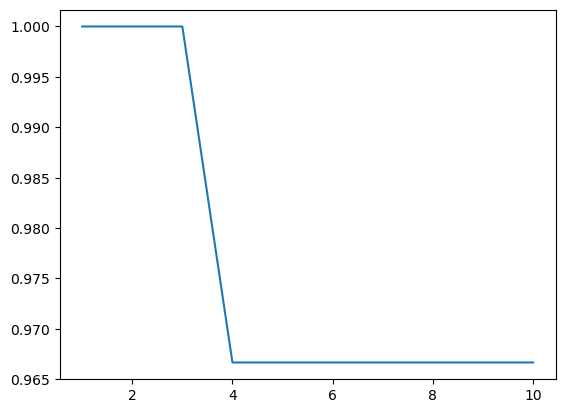

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
# ------------------------------------------------------------------------------
iris = pd.read_csv("Iris.csv")
X = iris.iloc[:, :-1].values
Y = iris.iloc[:, 5].values
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)
# ------------------------------------------------------------------------------
# Calculate the accuracy of the model for different values of k
ac = list()
for i in np.arange(1, 11):
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train, y_train)
  print("For k = %d accuracy is"%i, model.score(X_test,y_test))
  prediction = model.predict(X_test)
  ac.append(metrics.accuracy_score(prediction,y_test))
# ------------------------------------------------------------------------------
plt.plot(list(range(1,11)), ac)


**KNN & Cross Validation**

The optimal number of neighbors is: 11


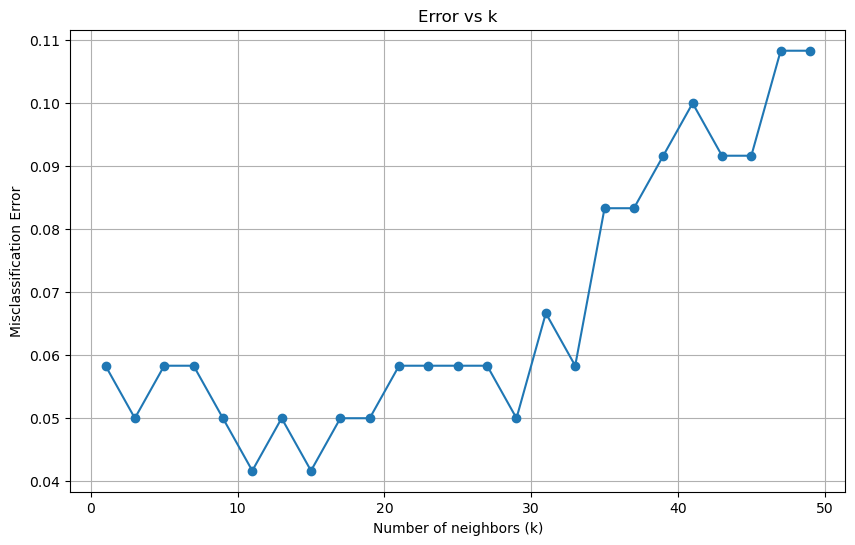

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# ------------------------------------------------
iris = pd.read_csv("IRIS.csv")

# Features and target
X = iris.iloc[:, 1:5].values   
Y = iris.iloc[:, 5].values  

# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

neighbors = []
cv_scores = []

# ------------------------------------------------
# Perform 10-fold cross validation
for k in range(1, 51, 2):
    neighbors.append(k)
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

# ------------------------------------------------
# Misclassification error
error = [1 - x for x in cv_scores]

# Determine best k
optimal_k = neighbors[error.index(min(error))]
print('The optimal number of neighbors is:', optimal_k)

# ------------------------------------------------
# Plot error vs k
plt.figure(figsize=(10, 6))
plt.plot(neighbors, error, marker='o')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Misclassification Error')
plt.title('Error vs k')
plt.grid(True)
plt.show()


**KNN on Diabetes**


Best K: 18

Accuracy: 0.7857142857142857

Confusion Matrix:

[[87 13]
 [20 34]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.63      0.67        54

    accuracy                           0.79       154
   macro avg       0.77      0.75      0.76       154
weighted avg       0.78      0.79      0.78       154



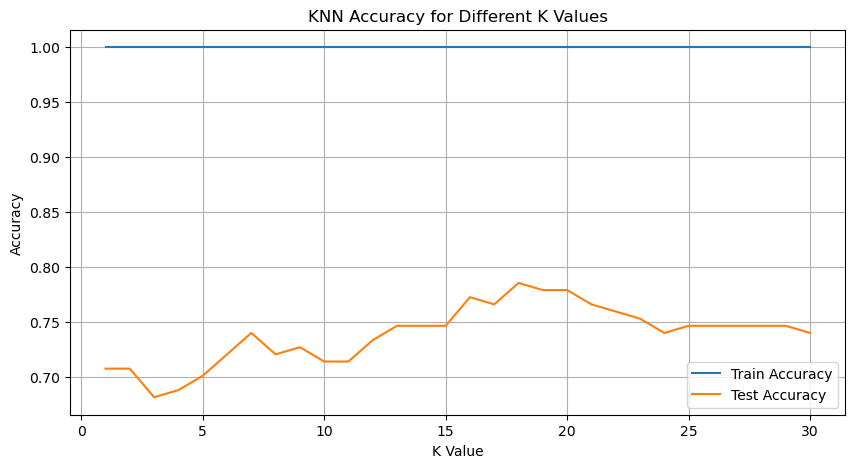

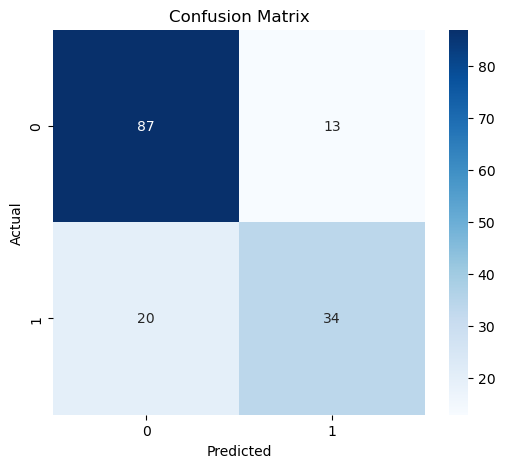

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------------------------
# Load dataset

df = pd.read_csv('diabetes2.csv')

# ------------------------------------------------------------------------------
# Features and target

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# ------------------------------------------------------------------------------
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------------------------
# Feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------------------------------------------
# Find best K

train_scores = []
test_scores = []

k_values = range(1, 31)

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='minkowski',
        p=2
    )

    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

# ------------------------------------------------------------------------------
# Best K

best_k = k_values[np.argmax(test_scores)]

print("Best K:", best_k)

# ------------------------------------------------------------------------------
# Train final model

model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    metric='minkowski',
    p=2
)

model.fit(X_train, y_train)

# ------------------------------------------------------------------------------
# Prediction

y_pred = model.predict(X_test)

# ------------------------------------------------------------------------------
# Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nConfusion Matrix:\n")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ------------------------------------------------------------------------------
# Plot accuracy vs K

plt.figure(figsize=(10, 5))

plt.plot(k_values, train_scores, label='Train Accuracy')
plt.plot(k_values, test_scores, label='Test Accuracy')

plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different K Values')

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------------------------
# Confusion matrix heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()
